In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu,wilcoxon,kruskal,permutation_test
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [2]:
df = pd.read_csv("movieReplicationSet.csv")

In [3]:
df.head()

,The Life of David Gale (2003),Wing Commander (1999),Django Unchained (2012),Alien (1979),Indiana Jones and the Last Crusade (1989),Snatch (2000),Rambo: First Blood Part II (1985),Fargo (1996),Let the Right One In (2008),Black Swan (2010),...,When watching a movie I cheer or shout or talk or curse at the screen,When watching a movie I feel like the things on the screen are happening to me,As a movie unfolds I start to have problems keeping track of events that happened earlier,"The emotions on the screen ""rub off"" on me - for instance if something sad is happening I get sad or if something frightening is happening I get scared",When watching a movie I get completely immersed in the alternative reality of the film,Movies change my position on social economic or political issues,When watching movies things get so intense that I have to stop watching,Gender identity (1 = female; 2 = male; 3 = self-described),Are you an only child? (1: Yes; 0: No; -1: Did not respond),Movies are best enjoyed alone (1: Yes; 0: No; -1: Did not respond)
0,NaN,NaN,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,...,1.0,6.0,2.0,5.0,5.0,5.0,1.0,1.0,0,1
1,NaN,NaN,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,6.0,5.0,3.0,2.0,1.0,0,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,4.0,3.0,5.0,5.0,4.0,4.0,1.0,1,0
3,NaN,NaN,2.0,NaN,3.0,NaN,NaN,NaN,NaN,4.0,...,3.0,1.0,1.0,4.0,5.0,3.0,1.0,1.0,0,1
4,NaN,NaN,3.5,NaN,0.5,NaN,0.5,1.0,NaN,0.0,...,2.0,3.0,2.0,5.0,6.0,4.0,4.0,1.0,1,1


In [4]:
df.columns

Index(['The Life of David Gale (2003)', 'Wing Commander (1999)',
       'Django Unchained (2012)', 'Alien (1979)',
       'Indiana Jones and the Last Crusade (1989)', 'Snatch (2000)',
       'Rambo: First Blood Part II (1985)', 'Fargo (1996)',
       'Let the Right One In (2008)', 'Black Swan (2010)',
       ...
       'When watching a movie I cheer or shout or talk or curse at the screen',
       'When watching a movie I feel like the things on the screen are happening to me',
       'As a movie unfolds I start to have problems keeping track of events that happened earlier',
       'The emotions on the screen "rub off" on me - for instance if something sad is happening I get sad or if something frightening is happening I get scared',
       'When watching a movie I get completely immersed in the alternative reality of the film',
       'Movies change my position on social economic or political issues',
       'When watching movies things get so intense that I have to stop watching',
 

In [5]:
total_rows = len(df)
missing_counts = df.isnull().sum()

In [6]:
missing_counts

The Life of David Gale (2003)                                              1021
Wing Commander (1999)                                                      1026
Django Unchained (2012)                                                     644
Alien (1979)                                                                808
Indiana Jones and the Last Crusade (1989)                                   634
                                                                           ... 
Movies change my position on social economic or political issues             20
When watching movies things get so intense that I have to stop watching      18
Gender identity (1 = female; 2 = male; 3 = self-described)                   24
Are you an only child? (1: Yes; 0: No; -1: Did not respond)                   0
Movies are best enjoyed alone (1: Yes; 0: No; -1: Did not respond)            0
Length: 477, dtype: int64

1) Are movies that are more popular (operationalized as having more ratings) rated higher than movies that
are less popular? [Hint: You can do a median-split of popularity to determine high vs. low popularity movies]

In [7]:
# Extracting only movie ratings
movies = df.iloc[:, :400]

popularity = movies.notna().sum()    
mean_rating = movies.mean(skipna=True) 

#now we are appending the above two features in the dataset
movie_stats = pd.DataFrame({
    'popularity': popularity,
    'mean_rating': mean_rating
})

In [8]:
# Median splitting based on popularity

med_popular = movie_stats['popularity'].median()
high_popular = movie_stats[movie_stats['popularity'] > med_popular]
low_popular = movie_stats[movie_stats['popularity'] <= med_popular]


In [9]:
movie_stats.head()

,popularity,mean_rating
The Life of David Gale (2003),76,2.151316
Wing Commander (1999),71,2.021127
Django Unchained (2012),453,3.153422
Alien (1979),289,2.707612
Indiana Jones and the Last Crusade (1989),463,2.778618


In [10]:
# Performing Man-Whitney U test
U, p = mannwhitneyu(high_popular['mean_rating'], low_popular['mean_rating'], alternative='two-sided')

In [11]:
U , p

(np.float64(35404.0), np.float64(1.6971433120157929e-40))

In [12]:
#Computing correlation 
n1, n2 = len(high_popular), len(low_popular)
ranking = 1 - (2 * U) / (n1 * n2)

In [13]:
print(f"Median popularity: {med_popular}")
print(f"Mean rating (high popularity): {high_popular['mean_rating'].mean():.2f}")
print(f"Mean rating (low popularity): {low_popular['mean_rating'].mean():.2f}")
print(f"Mann–Whitney U: {U:.1f}, p-value: {p:.2e}")
print(f"Rank correlation: {ranking:.2f}")
print(f"n_high = {n1}, n_low = {n2}")


Median popularity: 197.5
Mean rating (high popularity): 2.87
Mean rating (low popularity): 2.40
Mann–Whitney U: 35404.0, p-value: 1.70e-40
Rank correlation: -0.77
n_high = 200, n_low = 200


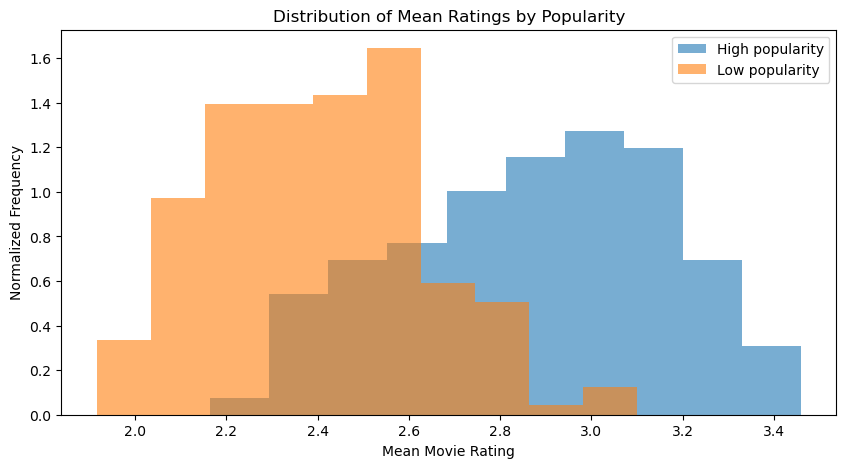

In [14]:
#Visualizing data
plt.figure(figsize=(10,5))
plt.hist(high_popular['mean_rating'], bins=10, alpha=0.6, label='High popularity', density=True)
plt.hist(low_popular['mean_rating'], bins=10, alpha=0.6, label='Low popularity', density=True)
plt.xlabel('Mean Movie Rating')
plt.ylabel('Normalized Frequency')
plt.title('Distribution of Mean Ratings by Popularity')
plt.legend()
plt.show()

A (Answer):
Given p < 0.005 and r ≈ −0.77, I conclude that less popular movies tend to receive higher ratings than more popular ones.
This effect is large and statistically significant.
A limitation is that popularity and rating may be correlated through sampling bias (only fans rate niche films), not necessarily film quality.

2) Are movies that are newer rated differently than movies that are older? [Hint: Do a median split of year of
release to contrast movies in terms of whether they are old or new]

In [15]:
# Extracting year from columns using RE function
def extract_year(title):
    match = re.search(r"\((\d{4})\)", title)
    return int(match.group(1)) if match else np.nan

years = [extract_year(c) for c in movies.columns]
mean_ratings = movies.mean(skipna=True)

In [16]:
# Combining into a DataFrame
movie_year = pd.DataFrame({
    'year': years,
    'mean_rating': mean_ratings
}).dropna()

# Median split by year
median_year = movie_year['year'].median()
old_movies = movie_year[movie_year['year'] <= median_year]
new_movies = movie_year[movie_year['year'] > median_year]


In [17]:
[old_movies,new_movies]

[                                           year  mean_rating
 Wing Commander (1999)                      1999     2.021127
 Alien (1979)                               1979     2.707612
 Indiana Jones and the Last Crusade (1989)  1989     2.778618
 Rambo: First Blood Part II (1985)          1985     2.365385
 Fargo (1996)                               1996     2.899606
 ...                                         ...          ...
 Patton (1970)                              1970     2.278689
 Anaconda (1997)                            1997     2.295455
 Twister (1996)                             1996     2.402299
 MacArthur (1977)                           1977     2.114754
 Look Who's Talking (1989)                  1989     2.337963
 
 [226 rows x 2 columns],
                                                 year  mean_rating
 The Life of David Gale (2003)                   2003     2.151316
 Django Unchained (2012)                         2012     3.153422
 Snatch (2000)              

In [18]:
# Mann–Whitney U test
U, p = mannwhitneyu(new_movies['mean_rating'], old_movies['mean_rating'], alternative='two-sided')

# Rank-biserial correlation
n1, n2 = len(new_movies), len(old_movies)
rank_biserial = 1 - (2 * U) / (n1 * n2)

In [19]:
print(f"Median release year: {median_year}")
print(f"Mean rating (new movies): {new_movies['mean_rating'].mean():.2f}")
print(f"Mean rating (old movies): {old_movies['mean_rating'].mean():.2f}")
print(f"Mann–Whitney U: {U:.1f}, p-value: {p:.2e}")
print(f"Rank-biserial correlation: {rank_biserial:.2f}")
print(f"n_new = {n1}, n_old = {n2}")

Median release year: 1999.0
Mean rating (new movies): 2.66
Mean rating (old movies): 2.62
Mann–Whitney U: 20949.0, p-value: 2.62e-01
Rank-biserial correlation: -0.07
n_new = 174, n_old = 226


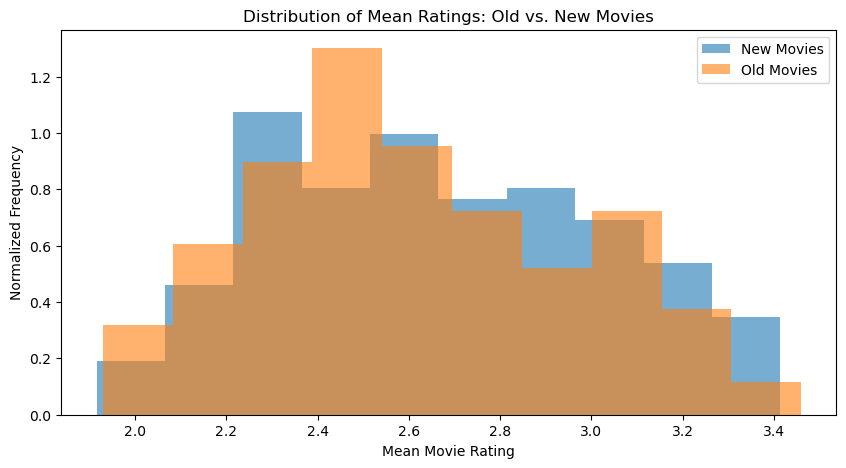

In [20]:
plt.figure(figsize=(10,5))
plt.hist(new_movies['mean_rating'], bins=10, alpha=0.6, label='New Movies', density=True)
plt.hist(old_movies['mean_rating'], bins=10, alpha=0.6, label='Old Movies', density=True)
plt.xlabel('Mean Movie Rating')
plt.ylabel('Normalized Frequency')
plt.title('Distribution of Mean Ratings: Old vs. New Movies')
plt.legend()
plt.show()

In [21]:
# Spearman correlation
from scipy.stats import spearmanr

rho, pval = spearmanr(movie_year['year'], movie_year['mean_rating'], nan_policy='omit')

print(f"Spearman correlation (rho): {rho:.3f}")
print(f"p-value: {pval:.3e}")

Spearman correlation (rho): 0.100
p-value: 4.576e-02


3) Is enjoyment of ‘Shrek (2001)’ gendered, i.e. do male and female viewers rate it differently?

In [22]:
# Extracting Shrek ratings and gender
shrek = df['Shrek (2001)']
gender = df.iloc[:,474] 

In [23]:
# Clean data
data = pd.DataFrame({'rating': shrek, 'gender': gender})
data = data[(data['gender'].isin([1, 2])) & (data['rating'].notna())]

# Split by gender
female = data[data['gender'] == 1]['rating']
male = data[data['gender'] == 2]['rating']

In [24]:
# Mann–Whitney U Test
u_stat, p_value = mannwhitneyu(female, male, alternative='two-sided')

# Rank-biserial correlation
n1, n2 = len(female), len(male)
r_rb = 1 - (2*u_stat) / (n1*n2)

In [25]:
print(f"U = {u_stat}, p = {p_value:.3e}, r_rb = {r_rb:.3f}")
print(f"Female mean = {female.mean():.2f}, Male mean = {male.mean():.2f}")

U = 96830.5, p = 5.054e-02, r_rb = -0.082
Female mean = 3.16, Male mean = 3.08


In [26]:
data

,rating,gender
0,3.0,1.0
1,3.0,1.0
2,3.5,1.0
3,0.5,1.0
4,3.0,1.0
...,...,...
1092,3.0,1.0
1093,4.0,1.0
1094,3.5,1.0
1095,2.5,1.0


C:\Users\adars\AppData\Local\Temp\ipykernel_13112\154758672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender_label", y="rating", data=data, palette="pastel", width=0.6)
C:\Users\adars\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 41.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\adars\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


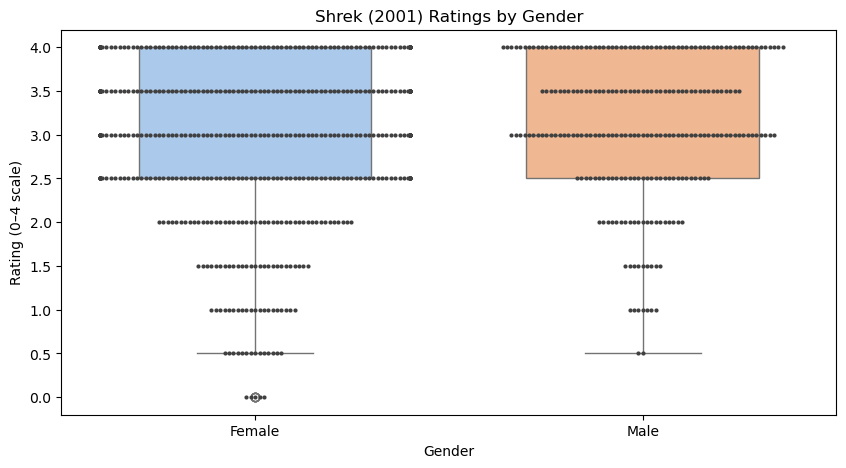

In [27]:
data["gender_label"] = data["gender"].replace({1: "Female", 2: "Male"})

plt.figure(figsize=(10, 5))
sns.boxplot(x="gender_label", y="rating", data=data, palette="pastel", width=0.6)
sns.swarmplot(x="gender_label", y="rating", data=data, color=".25", size=3)

plt.title("Shrek (2001) Ratings by Gender")
plt.xlabel("Gender")
plt.ylabel("Rating (0–4 scale)")
plt.show()

4) What proportion of movies are rated differently by male and female viewers?

In [28]:
gender = df.iloc[:, 474].replace(-1, pd.NA)

valid_genders = gender.isin([1, 2])
gender = gender[valid_genders]
df_movies = df.loc[valid_genders, df.columns[0:400]]

In [29]:
# --- Initialize counters ---
significant_count = 0
tested_count = 0
alpha = 0.005

# --- Loop over each movie column ---
for col in df_movies.columns:
    ratings = df_movies[col]
    data = pd.DataFrame({"rating": ratings, "gender": gender})
    data = data.dropna()

    if data["gender"].nunique() == 2: 
        female = data[data["gender"] == 1]["rating"]
        male = data[data["gender"] == 2]["rating"]

        if len(female) > 0 and len(male) > 0:
            u_stat, p_val = mannwhitneyu(female, male, alternative="two-sided")
            tested_count += 1
            if p_val < alpha:
                significant_count += 1

prop_diff = significant_count / tested_count
print(f"Movies tested: {tested_count}")
print(f"Movies with significant gender difference: {significant_count}")
print(f"Proportion: {prop_diff:.3f}")

Movies tested: 400
Movies with significant gender difference: 50
Proportion: 0.125


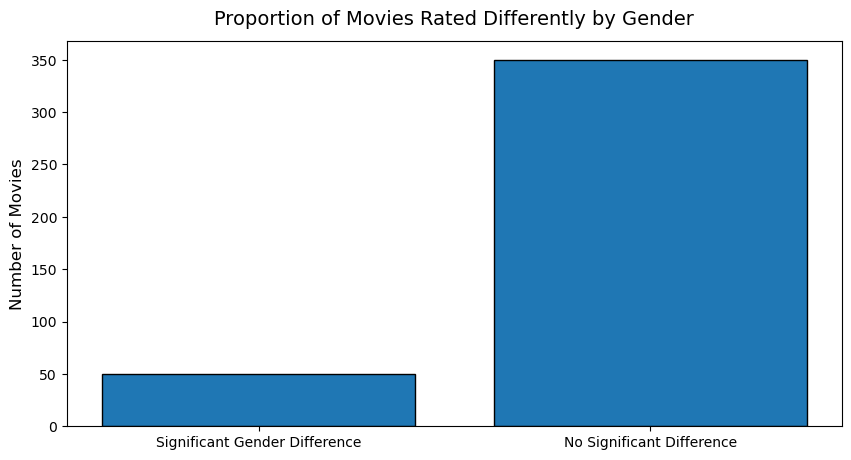

In [30]:
plt.figure(figsize=(10,5))

nonsig_count = tested_count - significant_count
labels = ['Significant Gender Difference', 'No Significant Difference']
values = [significant_count, nonsig_count]

bars = plt.bar(labels, values, edgecolor='black')
plt.title("Proportion of Movies Rated Differently by Gender", fontsize=14, pad=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.show()

5) Do people who are only children enjoy ‘The Lion King (1994)’ more than people with siblings?

In [31]:
lion_king = df["The Lion King (1994)"]
only_child = df.iloc[:, 475].replace(-1, pd.NA) 

In [32]:
# Drop missing
data = pd.DataFrame({"lion_king": lion_king, "only_child": only_child}).dropna()

# Split groups
only_chld = data[data["only_child"] == 1]["lion_king"]
siblings = data[data["only_child"] == 0]["lion_king"]

# Mann–Whitney U test
u_stat, p_val = mannwhitneyu(only_chld, siblings, alternative="two-sided")
r_rb = 1 - (2 * u_stat) / (len(only_chld) * len(siblings))

In [33]:
data

,lion_king,only_child
0,4.0,0
2,4.0,1
3,3.0,0
4,4.0,1
5,4.0,1
...,...,...
1090,3.5,0
1091,4.0,0
1092,3.5,0
1093,3.5,0


In [34]:
mean_only_chld = only_chld.mean()
mean_siblings = siblings.mean()

print(f"U = {u_stat:.1f}, p = {p_val:.3e}, r_rb = {r_rb:.3f}")
print(f"Only-child mean = {mean_only_chld:.2f}, With-siblings mean = {mean_siblings:.2f}")

U = 52929.0, p = 4.320e-02, r_rb = 0.097
Only-child mean = 3.35, With-siblings mean = 3.48


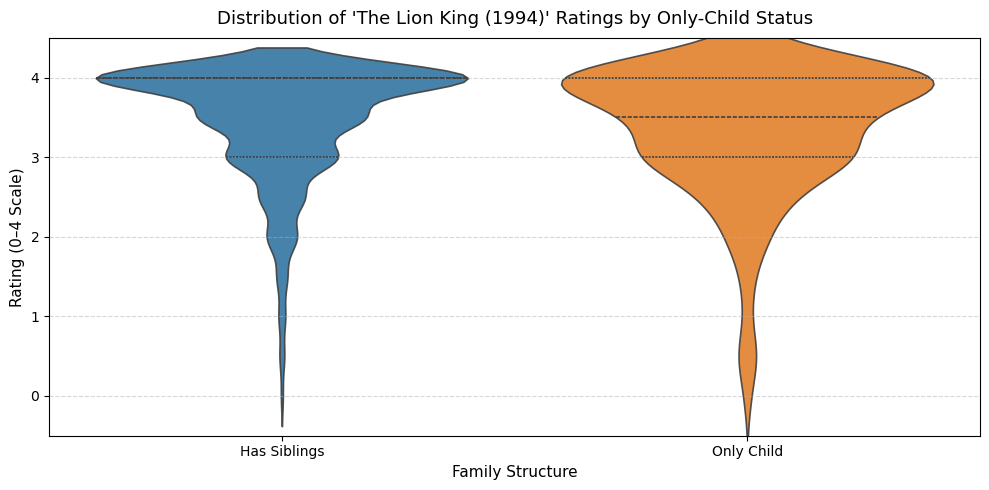

In [35]:
data["only_child_label"] = data["only_child"].replace({
    1: "Only Child",
    0: "Has Siblings"
})

plt.figure(figsize=(10,5))
sns.violinplot(
    data=data,
    x="only_child_label",
    y="lion_king",
    hue="only_child_label", 
    inner="quartile",
    fill=True,
    legend=False,
    linewidth=1.2,
    alpha=0.9
)

plt.title("Distribution of 'The Lion King (1994)' Ratings by Only-Child Status", fontsize=13, pad=10)
plt.xlabel("Family Structure", fontsize=11)
plt.ylabel("Rating (0–4 Scale)", fontsize=11)
plt.ylim(-0.5, 4.5)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

6)	What proportion of movies exhibit an “only child effect”, i.e. are rated different by viewers with siblings vs  those without?

In [36]:
only_child = df.iloc[:, 475].replace(-1, pd.NA)

valid_cases = only_child.isin([0, 1])
only_child = only_child[valid_cases]
df_movies = df.loc[valid_cases, df.columns[0:400]]

In [37]:
alpha = 0.005
significant_count = 0
tested_count = 0

# Loop over movies
for col in df_movies.columns:
    ratings = df_movies[col]
    data = pd.DataFrame({"rating": ratings, "only_child": only_child}).dropna()
    
    if data["only_child"].nunique() == 2:
        only = data[data["only_child"] == 1]["rating"]
        sibs = data[data["only_child"] == 0]["rating"]
        
        if len(only) > 0 and len(sibs) > 0:
            u_stat, p_val = mannwhitneyu(only, sibs, alternative="two-sided")
            tested_count += 1
            if p_val < alpha:
                significant_count += 1


In [38]:
prop_diff = significant_count / tested_count
print(f"Movies tested: {tested_count}")
print(f"Movies with significant only-child effect: {significant_count}")
print(f"Proportion: {prop_diff:.3f}")

Movies tested: 400
Movies with significant only-child effect: 7
Proportion: 0.018


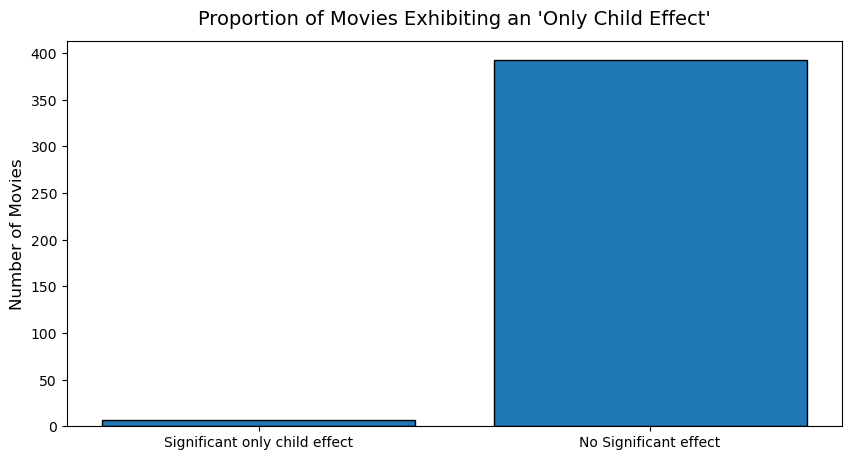

In [39]:
plt.figure(figsize=(10,5))

nonsig_count = tested_count - significant_count
labels = ['Significant only child effect', 'No Significant effect']
values = [significant_count, nonsig_count]

bars = plt.bar(labels, values, edgecolor='black')
plt.title("Proportion of Movies Exhibiting an 'Only Child Effect'", fontsize=14, pad=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.show()

7) Do people who like to watch movies socially enjoy ‘The Wolf of Wall Street (2013)’ more than those who
prefer to watch them alone?

In [40]:
wolf = df["The Wolf of Wall Street (2013)"]
social_pref = df.iloc[:, 476].replace(-1, pd.NA)  # 0=social, 1=alone

In [41]:
data = pd.DataFrame({
    "wolf": wolf,
    "social_pref": social_pref
}).dropna()

# Split groups
social = data[data["social_pref"] == 0]["wolf"]
alone = data[data["social_pref"] == 1]["wolf"]

In [42]:
# Mann–Whitney U test
u_stat, p_val = mannwhitneyu(social, alone, alternative="two-sided")
r_rb = 1 - (2 * u_stat) / (len(social) * len(alone))

mean_social = social.mean()
mean_alone = alone.mean()

print(f"U = {u_stat:.1f}, p = {p_val:.3e}, r_rb = {r_rb:.3f}")
print(f"Social watchers mean = {mean_social:.2f}, Solo watchers mean = {mean_alone:.2f}")

U = 49303.5, p = 1.128e-01, r_rb = 0.071
Social watchers mean = 3.03, Solo watchers mean = 3.14


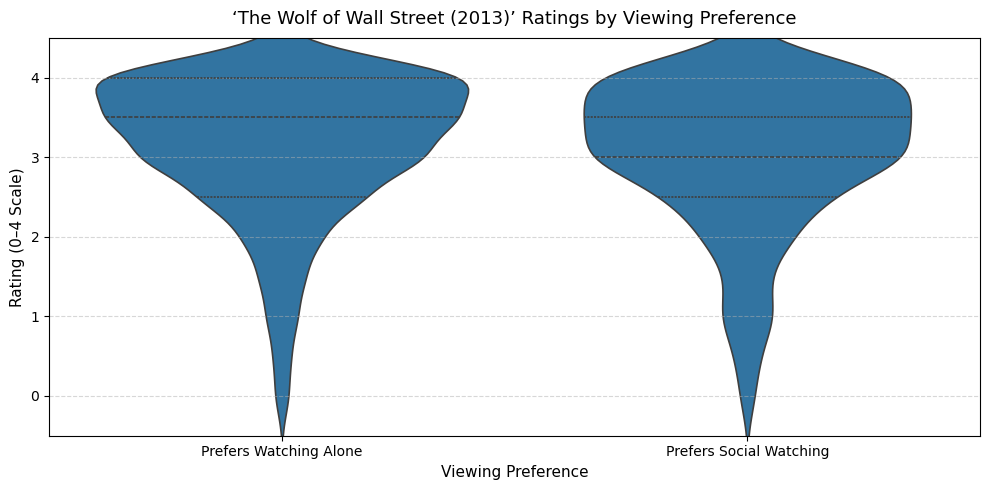

In [43]:
data["preference_label"] = data["social_pref"].replace({
    0: "Prefers Social Watching",
    1: "Prefers Watching Alone"
})

plt.figure(figsize=(10,5))
sns.violinplot(
    data=data,
    x="preference_label",
    y="wolf",
    inner="quartile",
    linewidth=1.2
)

plt.title("‘The Wolf of Wall Street (2013)’ Ratings by Viewing Preference", fontsize=13, pad=10)
plt.xlabel("Viewing Preference", fontsize=11)
plt.ylabel("Rating (0–4 Scale)", fontsize=11)
plt.ylim(-0.5, 4.5)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

8) What proportion of movies exhibit such a “social watching” effect?

In [44]:
movie_cols = df.columns[1:401] 
social_col = df.columns[476] 

# Removing invalid codes (-1 means missing/no response)
data = df[df[social_col] != -1]

In [45]:
sig_movies = 0
alpha = 0.005  # significance threshold
p_values = []

for movie in movie_cols:
    group_social = data[data[social_col] == 0][movie].dropna()
    group_solo = data[data[social_col] == 1][movie].dropna()
    
    # Skip movies with no data in one group
    if len(group_social) > 0 and len(group_solo) > 0:
        stat, p = mannwhitneyu(group_social, group_solo, alternative='two-sided', nan_policy='omit')
        p_values.append(p)
        if p < alpha:
            sig_movies += 1

In [46]:
# --- Compute proportion ---
total_movies = len(movie_cols)
proportion = sig_movies / total_movies

print(f"Movies tested: {total_movies}")
print(f"Movies with significant social-watching effect: {sig_movies}")
print(f"Proportion: {proportion:.3f}")

Movies tested: 400
Movies with significant social-watching effect: 10
Proportion: 0.025


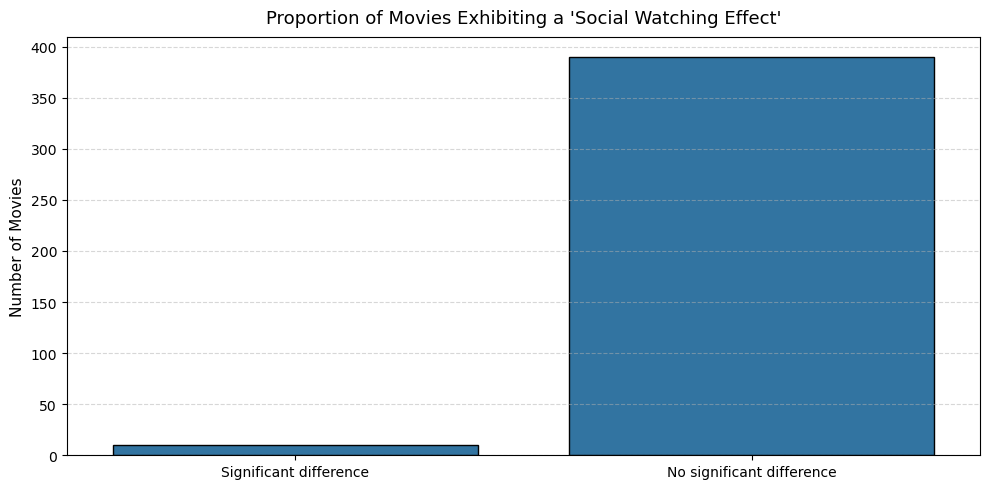

In [47]:
results = {
    "Significant difference": sig_movies,
    "No significant difference": total_movies - sig_movies
}

plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), edgecolor="black")
plt.title("Proportion of Movies Exhibiting a 'Social Watching Effect'", fontsize=13, pad=10)
plt.ylabel("Number of Movies", fontsize=11)
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

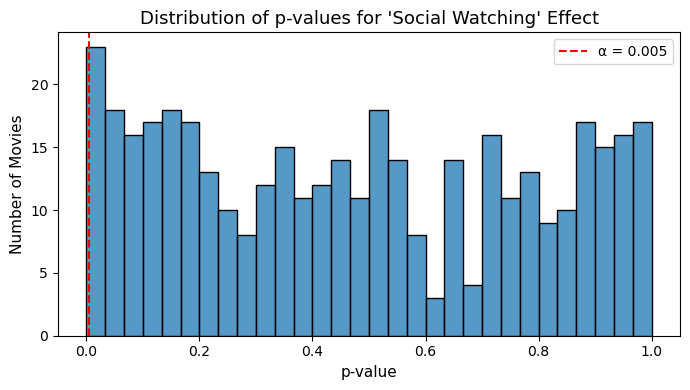

In [48]:
plt.figure(figsize=(7,4))
sns.histplot(p_values, bins=30, edgecolor="black")
plt.axvline(alpha, color="red", linestyle="--", label=f"α = {alpha}")
plt.title("Distribution of p-values for 'Social Watching' Effect", fontsize=13)
plt.xlabel("p-value", fontsize=11)
plt.ylabel("Number of Movies", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

9) Is the ratings distribution of ‘Home Alone (1990)’ different than that of ‘Finding Nemo (2003)’?

In [49]:
movie1 = 'Home Alone (1990)'
movie2 = 'Finding Nemo (2003)'

# Drop rows where either rating is missing
paired_data = df[[movie1, movie2]].dropna()

In [50]:
#Wilcoxon signed-rank test
stat, p = wilcoxon(paired_data[movie1], paired_data[movie2], alternative='two-sided')

# Compute descriptive stats
mean1 = paired_data[movie1].mean()
mean2 = paired_data[movie2].mean()
n = len(paired_data)

In [51]:
print(f"n = {n}")
print(f"{movie1} mean = {mean1:.2f}")
print(f"{movie2} mean = {mean2:.2f}")
print(f"Wilcoxon statistic = {stat:.1f}, p = {p:.3e}")

n = 810
Home Alone (1990) mean = 3.13
Finding Nemo (2003) mean = 3.40
Wilcoxon statistic = 41298.5, p = 3.910e-17


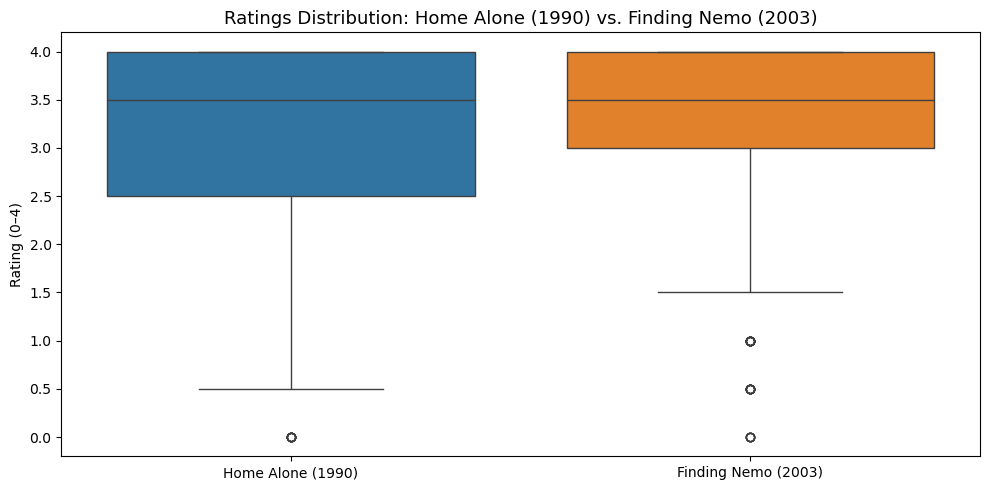

In [52]:
plt.figure(figsize=(10,5))
sns.boxplot(data=paired_data[[movie1, movie2]], orient='v')
plt.title("Ratings Distribution: Home Alone (1990) vs. Finding Nemo (2003)", fontsize=13)
plt.ylabel("Rating (0–4)")
plt.tight_layout()
plt.show()

10) There are ratings on movies from several franchises ([‘Star Wars’, ‘Harry Potter’, ‘The Matrix’, ‘Indiana
Jones’, ‘Jurassic Park’, ‘Pirates of the Caribbean’, ‘Toy Story’, ‘Batman’]) in this dataset. How many of these
are of inconsistent quality, as experienced by viewers? [Hint: You can use the keywords in quotation marks
featured in this question to identify the movies that are part of each franchise]

In [53]:
# Define franchise keywords
franchises = [
    'Star Wars', 'Harry Potter', 'The Matrix', 
    'Indiana Jones', 'Jurassic Park', 
    'Pirates of the Caribbean', 'Toy Story', 'Batman'
]

movie_cols = df.columns[1:401]

In [54]:
# Dictionary to store results
franchise_results = {}

alpha = 0.005

# Loop through each franchise
for franchise in franchises:
    # Find all movies containing this franchise keyword
    movies = [col for col in movie_cols if franchise.lower() in col.lower()]
    
    if len(movies) > 1:  # need at least 2 movies to compare
        # Prepare ratings for each movie
        groups = [df[m].dropna() for m in movies]
        # Kruskal–Wallis H-test
        stat, p = kruskal(*groups)
        franchise_results[franchise] = {
            'n_titles': len(movies),
            'H': stat,
            'p': p,
            'inconsistent': p < alpha
        }

In [55]:
# Summary
inconsistent_count = sum(v['inconsistent'] for v in franchise_results.values())
total_franchises = len(franchise_results)

print("Franchise consistency results:")
for name, res in franchise_results.items():
    print(f"{name}: n = {res['n_titles']}, H = {res['H']:.2f}, p = {res['p']:.3e}, inconsistent = {res['inconsistent']}")

print(f"\nTotal franchises tested: {total_franchises}")
print(f"Franchises with inconsistent quality: {inconsistent_count}")

Franchise consistency results:
Star Wars: n = 6, H = 230.58, p = 8.016e-48, inconsistent = True
Harry Potter: n = 4, H = 3.33, p = 3.433e-01, inconsistent = False
The Matrix: n = 3, H = 48.38, p = 3.124e-11, inconsistent = True
Indiana Jones: n = 4, H = 45.79, p = 6.273e-10, inconsistent = True
Jurassic Park: n = 3, H = 46.59, p = 7.637e-11, inconsistent = True
Pirates of the Caribbean: n = 3, H = 20.64, p = 3.290e-05, inconsistent = True
Toy Story: n = 3, H = 24.39, p = 5.066e-06, inconsistent = True
Batman: n = 3, H = 190.53, p = 4.225e-42, inconsistent = True

Total franchises tested: 8
Franchises with inconsistent quality: 7


C:\Users\adars\AppData\Local\Temp\ipykernel_13112\426278216.py:13: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=plot_df, x='Franchise', y='Rating', inner='quartile', scale='width')


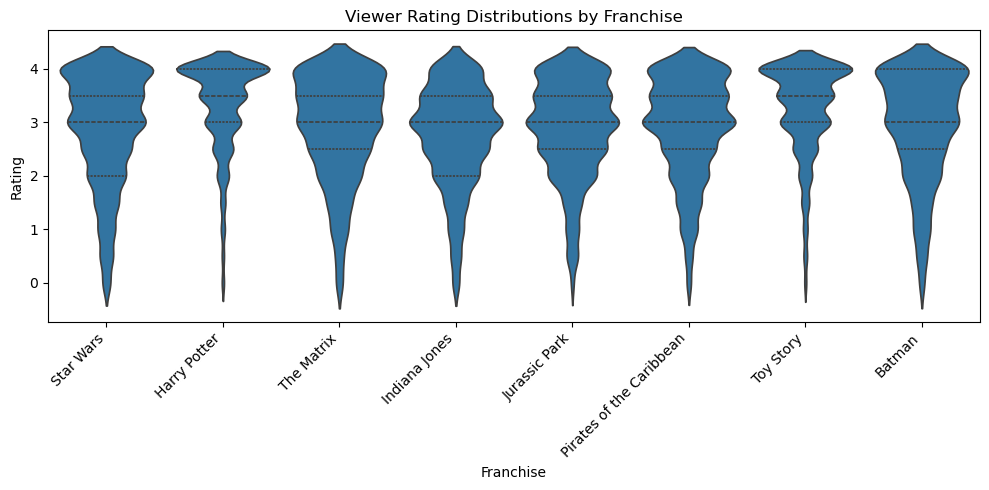

In [56]:
all_data = []

for franchise in franchises:
    movies = [col for col in movie_cols if franchise.lower() in col.lower()]
    if len(movies) > 1:
        melted = df[movies].melt(var_name='Movie', value_name='Rating')
        melted['Franchise'] = franchise
        all_data.append(melted)

plot_df = pd.concat(all_data, ignore_index=True)

plt.figure(figsize=(10,5))
sns.violinplot(data=plot_df, x='Franchise', y='Rating', inner='quartile', scale='width')
plt.title("Viewer Rating Distributions by Franchise")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Extra Credit: Tell us something interesting and true (supported by a significance test of some kind) about the
movies in this dataset that is not already covered by the questions above [for 5% of the grade score].

We want to check if there is gender bias towards female led movies and we will be using permutation test here


In [57]:
female_led = [
    "Alien (1979)", "Aliens (1986)", "Black Swan (2010)", "Carrie (1976)",
    "Clueless (1995)", "Divine Secrets of the Ya-Ya Sisterhood (2002)",
    "Fatal Attraction (1987)", "Ghostbusters (2016)", "Girl, Interrupted (1999)",
    "My Best Friend’s Wedding (1997)", "Rosemary’s Baby (1968)", "Room (2015)",
    "Runaway Bride (1999)", "Terms of Endearment (1983)", "The Blue Lagoon (1980)",
    "The Descent (2005)", "The Others (2001)", "The Proposal (2009)",
    "The Silence of the Lambs (1991)", "Uptown Girls (2003)"
]

# --- Extract only movie columns ---
movie_cols = df.columns[1:401]  # assuming first column = ID or demographics

# --- Find which columns match female-led titles ---
female_cols = [col for col in movie_cols if any(name in col for name in female_led)]
other_cols = [col for col in movie_cols if col not in female_cols]

In [58]:
df["female_led_mean"] = df[female_cols].mean(axis=1, skipna=True)
df["other_mean"] = df[other_cols].mean(axis=1, skipna=True)

In [59]:
valid = df[["female_led_mean", "other_mean"]].dropna()

obs_diff = valid["female_led_mean"].mean() - valid["other_mean"].mean()

In [60]:
res = permutation_test(
    (valid["female_led_mean"], valid["other_mean"]),
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    permutation_type='independent',
    n_resamples=10000,
    alternative='two-sided',
    random_state=42
)

print(f"Observed mean difference: {obs_diff:.3f}")
print(f"p-value: {res.pvalue:.5f}")

Observed mean difference: 0.026
p-value: 0.32657


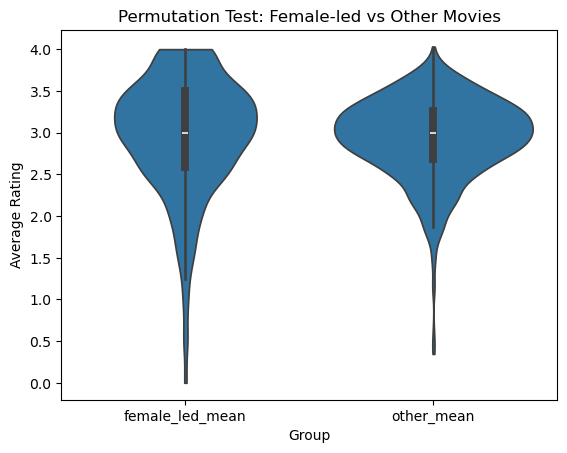

In [61]:
melted = valid.melt(value_vars=["female_led_mean", "other_mean"],
                    var_name="Group", value_name="Average Rating")

sns.violinplot(x="Group", y="Average Rating", data=melted, inner="box", cut=0)
plt.title("Permutation Test: Female-led vs Other Movies")
plt.show()